Paula Andre C Cano- Pamela Huacca 

In [1]:
import numpy as np
import scipy.io as sio
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

In [9]:
data = sio.loadmat(r"C:\Users\USER\Documents\LaboratorioBioseniales\signals.mat")
data
data.keys()

dict_keys(['__header__', '__version__', '__globals__', 'Fs', 'ECG_asRecording', 'ECG_filtered', 'EMG_filtered1', 'EMG_filtered2', 'EMG_asRecording1', 'EMG_asRecording2'])

In [10]:
# Implementación de funciones

def RMS_value(signal):
    return np.sqrt(np.mean(signal**2))

# Análisis estadístico de las señal ECG

In [11]:
# Tiempo de la señal
num_muestras = data['ECG_filtered'].shape[1]
Ts = 1/data['Fs'] 
t = num_muestras * Ts 
T = np.arange(0, t, Ts) # Vector de tiempo
print(f"Tiempo total de la señal: {t} segundos")


Tiempo total de la señal: [[30.]] segundos


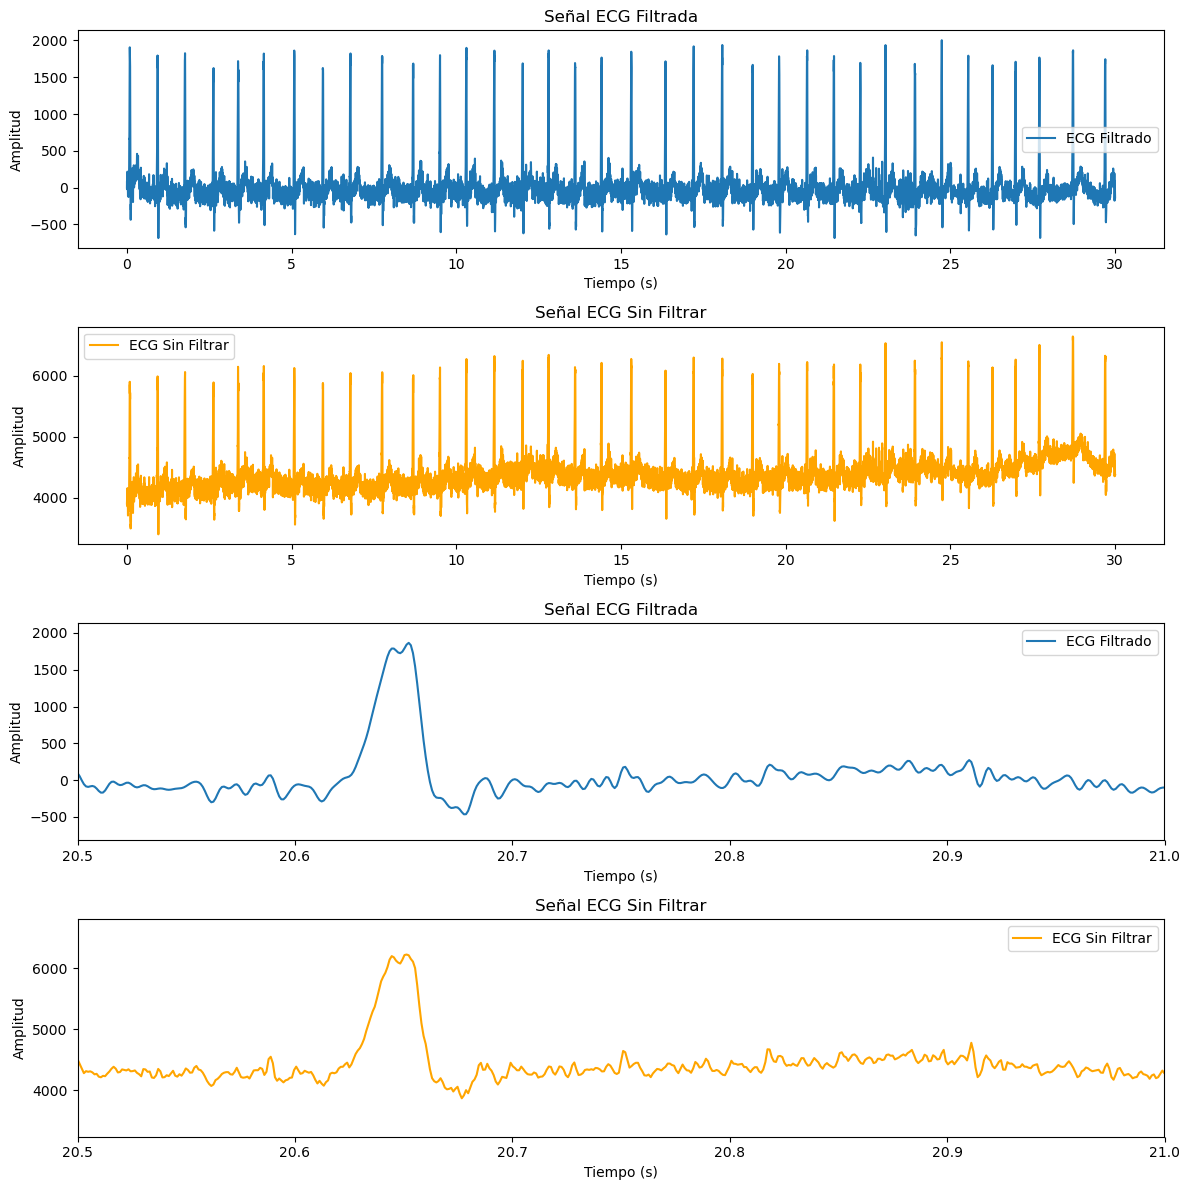

In [12]:
# Gráfica de la señal ECG filtrada y sin filtrar
plt.figure(figsize=(12, 12))
plt.subplot(4, 1, 1)
plt.plot(T, data['ECG_filtered'][0], label='ECG Filtrado')
plt.title('Señal ECG Filtrada')
plt.xlabel('Tiempo (s)')
plt.ylabel('Amplitud') 
plt.legend()
plt.subplot(4, 1, 2)
plt.plot(T, data['ECG_asRecording'][0], label='ECG Sin Filtrar', color='orange')
plt.title('Señal ECG Sin Filtrar')
plt.xlabel('Tiempo (s)')
plt.ylabel('Amplitud')
plt.legend()
plt.subplot(4, 1, 3)
plt.plot(T, data['ECG_filtered'][0], label='ECG Filtrado')
plt.xlim(20.5, 21) 
plt.title('Señal ECG Filtrada')
plt.xlabel('Tiempo (s)')
plt.ylabel('Amplitud') 
plt.legend()
plt.subplot(4, 1, 4)
plt.plot(T, data['ECG_asRecording'][0], label='ECG Sin Filtrar', color='orange')
plt.xlim(20.5, 21)
plt.title('Señal ECG Sin Filtrar')
plt.xlabel('Tiempo (s)')
plt.ylabel('Amplitud')
plt.legend()
plt.tight_layout()

- En la señal sin filtro se observa una tendencia de la señal a crear un tipo de rampa, esto se atribuye bajas frecuencias, siendo más notorias entre los segundos 20 y 30. Para la aliminación de estas se aplica un filtro pasa altas que deje por fuera estas señales, al aplicarlo se evidencia la eliminación de estas curvas amplias, aplanando un poco la señal, como se observa en la señal filtrada.
- Se nota también que el offset de la señal sin filtrar está alrededor de los 4000 o 4500 y la filtrada se centrada en cero.
- El rango de interés de la señal ECG es de 0.05 Hz a 100 Hz. Si se aplica un filtrp pasabandas en ese rango, será necesario aplicar un filtro Notch para eliminar el ruido de 60 Hz de la red eléctrica, en la gráfica acotada en 0.5 segundos se puede notar que la oscilaciones rápidas desaperecen un poco, en la señal filtrada presenta un trazo un poco más limpio.

Análisis del ciclo cardíaco sin filtrar:
Valor RMS: 4160.8849
Valor promedio: 4144.5206
Valor de la varianza: 135912.2605
Valor de la desviación estándar: 368.6628


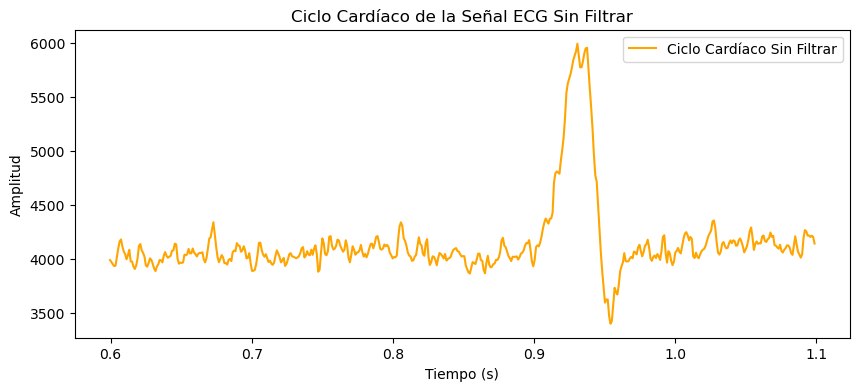

In [13]:
# Análisis de un único ciclo cardíaco de la señal sin filtrar

t_inicio = 0.6
t_fin = 1.1

idx_inicio = int(t_inicio / Ts)
idx_fin = int(t_fin / Ts)
ciclo = data['ECG_asRecording'][0][idx_inicio:idx_fin]
T_ciclo = T[idx_inicio:idx_fin]

plt.figure(figsize=(10, 4))
plt.plot(T_ciclo, ciclo, label='Ciclo Cardíaco Sin Filtrar', color='orange')
plt.title('Ciclo Cardíaco de la Señal ECG Sin Filtrar')
plt.xlabel('Tiempo (s)')
plt.ylabel('Amplitud')
plt.legend()


# Cálculo del valor RMS del ciclo cardíaco sin filtrar
print("Análisis del ciclo cardíaco sin filtrar:")
rms= RMS_value(ciclo)
print(f"Valor RMS: {rms:.4f}")
promedio= np.mean(ciclo)
print(f"Valor promedio: {promedio:.4f}")
var = np.var(ciclo)
print(f"Valor de la varianza: {var:.4f}") 
std = np.std(ciclo)
print(f"Valor de la desviación estándar: {std:.4f}")

Análisis del ciclo cardíaco filtrado:
Valor RMS: 362.4985
Valor promedio: 9.3836
Valor de la varianza: 131317.1197
Valor de la desviación estándar: 362.3770


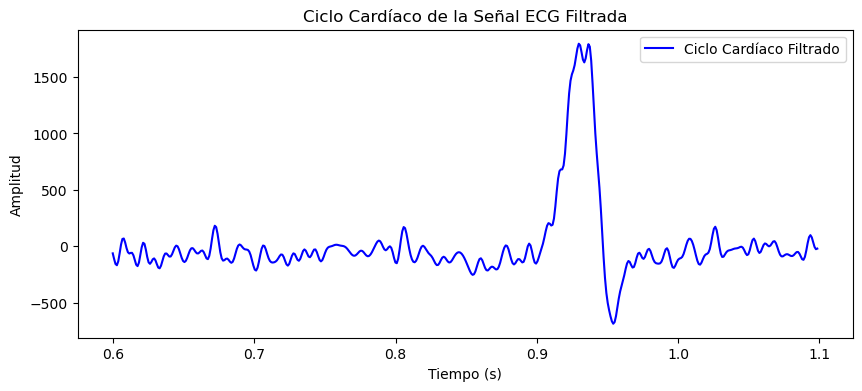

In [14]:
t_inicio = 0.6
t_fin = 1.1

idx_inicio = int(t_inicio / Ts)
idx_fin = int(t_fin / Ts)
ciclo_ = data['ECG_filtered'][0][idx_inicio:idx_fin]
T_ciclo = T[idx_inicio:idx_fin]

plt.figure(figsize=(10, 4))
plt.plot(T_ciclo, ciclo_, label='Ciclo Cardíaco Filtrado', color='blue')
plt.title('Ciclo Cardíaco de la Señal ECG Filtrada')
plt.xlabel('Tiempo (s)')
plt.ylabel('Amplitud')
plt.legend()


# Cálculo del valor RMS del ciclo cardíaco filtrado
print("Análisis del ciclo cardíaco filtrado:")
rms_ = RMS_value(ciclo_)
print(f"Valor RMS: {rms_:.4f}")
promedio_ = np.mean(ciclo_)
print(f"Valor promedio: {promedio_:.4f}")
var_ = np.var(ciclo_)
print(f"Valor de la varianza: {var_:.4f}") 
std_ = np.std(ciclo_)
print(f"Valor de la desviación estándar: {std_:.4f}")

- Se observa un cambio notorio en los resultados obtenidos para cada segmento de señal, especialmente en el promedio que se ve seriamente afectado por la ubicación general debido al voltaje de offset de la señal sin filtrar, esto da una representación numperica de la utilidad del filtro de paso de banda.
- En los resultados de la señal sin filtrar se observa una diferencia significativa entre el valor RMS y la desviación estandar de la señal, de nuevo, afectado por la ubicacipon general de la señal. En cambio, en la señal filtrada notamos que estos dos valores son casi idénticos, lo que da cuenta de que la media de la señal es muy cercana a cero en ese caso.
- En cuanto a la varianza y la desviación estandar, estos valores se mantuvieron relativamente cercanos, esto debido a que miden la oscialción respecto a su centro. El cambio que se ve en la desviación estandar puede reresentar la eliminación del ruido de frecuencias más altas.



Text(0, 0.5, 'Amplitud')

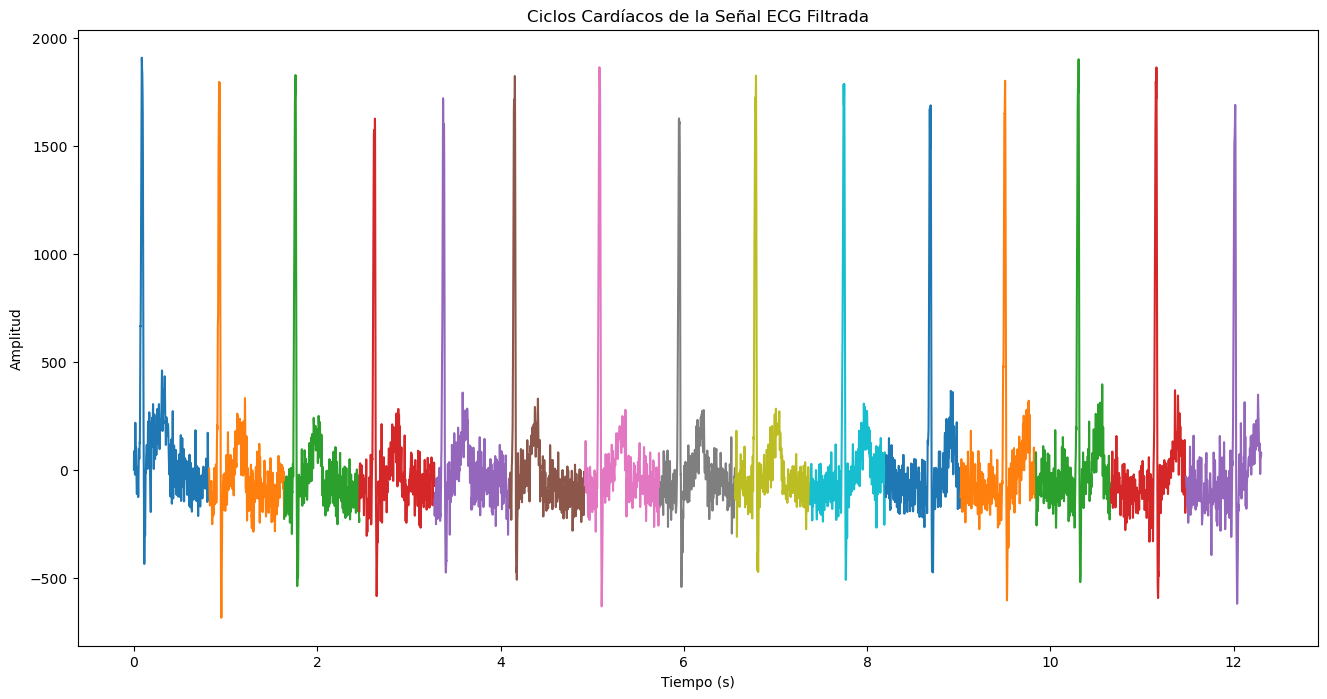

In [15]:
# Análisis de 15 ciclos de la señal ECG filtrada

# t_inicio = 0
# t_fin = 12.5

# idx_inicio = int(t_inicio / Ts)
# idx_fin = int(t_fin / Ts)
# ciclo = data['ECG_filtered'][0][idx_inicio:idx_fin]
# T_ciclo = T[idx_inicio:idx_fin]
# plt.plot(T_ciclo, ciclo, label='Ciclo Cardíaco Filtrado', color='blue')

promedios = []
varianzas = []
periodo_ciclos = 0.82
duracion_ciclo = 0.82

plt.figure(figsize=(16, 8))

for i in range(0, 15):
    t_inicio = i * periodo_ciclos
    t_fin = t_inicio + duracion_ciclo

    idx_inicio = int(t_inicio / Ts)
    idx_fin = int(t_fin / Ts)
    ciclo = data['ECG_filtered'][0][idx_inicio:idx_fin]
    T_ciclo = T[idx_inicio:idx_fin]

    plt.plot(T_ciclo, ciclo)
    
    promedios.append(np.mean(ciclo))
    varianzas.append(np.var(ciclo))

plt.title('Ciclos Cardíacos de la Señal ECG Filtrada')
plt.xlabel('Tiempo (s)')
plt.ylabel('Amplitud')

In [16]:
promedios

[89.72531476474666,
 -7.241253456150445,
 -11.900049230023384,
 -4.627472546021548,
 9.584219083893437,
 -6.088529085139393,
 10.158209161218847,
 2.6217557921751147,
 9.656927353818133,
 15.851343936535207,
 0.4694355333597828,
 -4.623871482895863,
 12.244476197150178,
 -7.705908259903823,
 -7.113384884705331]

In [17]:
varianzas

[95395.87984398268,
 88449.37401965885,
 85308.30639551154,
 74239.11678883334,
 77346.29627540275,
 87190.3769483129,
 87994.90084320928,
 72902.66617198903,
 83870.95785364484,
 83634.11516310004,
 75647.28573379916,
 81355.88479406184,
 90039.12626284795,
 90632.82649232603,
 80529.46248415532]

Una señal es estacionaria cuando sus propiedades estadísticas no cambian con el tiempo[1]. Los valores de la media obtenidos se encuentran en su mayoría cercanos a cero, variando aproximadamente entre −12 y 16. Sin embargo, el primer ciclo presenta un valor promedio mayor (≈89), lo cual puede atribuirse a un posible efecto transitorio al inicio de la señal o al proceso de segmentación. A pesar de esto, no se observa una tendencia creciente o decreciente en las medias a lo largo de los ciclos. En cuanto a la varianza, los valores se mantienen dentro de un rango similar, aproximadamente entre 72900 y 95395, lo que indica que la dispersión o variabilidad de la señal es relativamente constante entre los distintos ciclos.

Adicionalmente, al observar la gráfica de los 15 ciclos cardíacos, se aprecia que todos presentan una morfología similar y amplitudes comparables, especialmente en el complejo QRS característico del ECG, lo cual sugiere que el comportamiento de la señal se mantiene estable a lo largo del tiempo.

Por lo tanto, considerando el comportamiento de la media, la varianza y la gráfica de la señal, se puede concluir que la señal puede considerarse aproximadamente estacionaria en el intervalo analizado.

In [18]:
import scipy.stats as stats

In [19]:
# Análisis de dos ciclos específicos (Dos comparaciones diferentes)
# Comparación 1

ciclo1 = data['ECG_filtered'][0][int((0.82*2) / Ts):int((0.82*3) / Ts)]
ciclo2 = data['ECG_filtered'][0][int((0.82*10) / Ts):int((0.82*11) / Ts)]

stat1, p1 = stats.shapiro(ciclo1)
stat2, p2 = stats.shapiro(ciclo2)

a = 0.05
print("Comparación 1")
print(f"Ciclo 1: p-valor={p1:.4f}")
print(f"Ciclo 2: p-valor={p2:.4f}")

stat_levene, p_levene = stats.levene(ciclo1, ciclo2)
print(f"Prueba de Levene p-valor={p_levene:.4f}")

if p1 > a and p2 > a and p_levene > a:
    
    print("Se cumplen los supuestos → Se aplica prueba t")

    t_stat, p_t = stats.ttest_ind(ciclo1, ciclo2)
    print(f"Prueba t p-valor={p_t:.4f}")

else:
    
    print("No se cumplen los supuestos → Mann-Whitney")

    u_stat, p_u = stats.mannwhitneyu(ciclo1, ciclo2)
    print(f"Prueba Mann-Whitney p-valor={p_u:.4f}")




Comparación 1
Ciclo 1: p-valor=0.0000
Ciclo 2: p-valor=0.0000
Prueba de Levene p-valor=0.5728
No se cumplen los supuestos → Mann-Whitney
Prueba Mann-Whitney p-valor=0.0026


In [ ]:
# Comparación 2

ciclo3 = data['ECG_filtered'][0][int((0.82*4) / Ts):int((0.82*5) / Ts)]
ciclo4 = data['ECG_filtered'][0][int((0.82*12) / Ts):int((0.82*13) / Ts)]

stat3, p3 = stats.shapiro(ciclo3)
stat4, p4 = stats.shapiro(ciclo4)

print("\nComparación 2")
print(f"Ciclo 3: p-valor={p3:.4f}")
print(f"Ciclo 4: p-valor={p4:.4f}")

stat_levene2, p_levene2 = stats.levene(ciclo3, ciclo4)
print(f"Prueba de Levene p-valor={p_levene2:.4f}")

if p3 > a and p4 > a and p_levene2 > a:
    
    print("Se cumplen los supuestos → Se aplica prueba t")

    t_stat2, p_t2 = stats.ttest_ind(ciclo3, ciclo4)
    print(f"Prueba t p-valor={p_t2:.4f}")

else:
    
    print("No se cumplen los supuestos → Mann-Whitney")

    u_stat2, p_u2 = stats.mannwhitneyu(ciclo3, ciclo4)
    print(f"Prueba Mann-Whitney p-valor={p_u2:.4f}")


Comparación 2
Ciclo 3: p-valor=0.0000
Ciclo 4: p-valor=0.0000
Prueba de Levene p-valor=0.9682
No se cumplen los supuestos → Mann-Whitney
Prueba Mann-Whitney p-valor=0.5867


 Primero se verificó el supuesto de normalidad mediante la prueba de Shapiro-Wilk, obteniéndose p ≈ 0.0000, por lo que se rechazó la hipótesis de normalidad. Debido a que no se cumple este supuesto, no es apropiado aplicar una prueba t paramétrica. Por esta razón se utilizó la prueba no paramétrica U de Mann-Whitney para comparar los ciclos.

En la primera comparación se obtuvo p = 0.0026, lo que indica que existen diferencias estadísticamente significativas entre los ciclos analizados. En la segunda comparación se obtuvo p = 0.5867, por lo que no se encontraron diferencias estadísticas significativas entre esos ciclos. Estos resultados sugieren que la señal presenta un comportamiento aproximadamente estacionario en algunos segmentos, aunque pueden existir variaciones entre ciertos ciclos, lo cual es esperable en señales fisiológicas como el ECG.

In [21]:
#prueba de dickey fuller 
from statsmodels.tsa.stattools import adfuller

resultado = adfuller(data['ECG_filtered'][0])

print("Estadístico ADF:", resultado[0])
print("p-valor:", resultado[1])

alpha = 0.05

if resultado[1] < alpha:
    print("Se rechaza H0 → la señal es estacionaria")
else:
    print("No se rechaza H0 → la señal no es estacionaria")

Estadístico ADF: -28.274305946269656
p-valor: 0.0
Se rechaza H0 → la señal es estacionaria


Para verificar la estacionariedad de la señal ECG filtrada se aplicó la prueba de Dickey-Fuller aumentada (ADF). El resultado arrojó un p-valor  igual a 0 (p ≈ 0.0000), el cual es menor que el nivel de significancia α = 0.05. Por lo tanto, se rechaza la hipótesis nula de no estacionariedad, concluyendo que la señal presenta comportamiento aproximadamente estacionario en el intervalo analizado. Este resultado es consistente con el análisis previo entre ciclos, donde en algunos casos no se encontraron diferencias estadísticamente significativas entre segmentos de la señal.

Concluciones


Se analizó una señal ECG observando inicialmente la señal original, en la cual se identificó la presencia de ruido e interferencias. Posteriormente, al aplicar el filtrado, se obtuvo una señal más limpia que permitió visualizar con mayor claridad los ciclos cardíacos y facilitar su análisis.

El análisis estadístico mostró que la señal no sigue una distribución normal según la prueba de Shapiro-Wilk (p ≈ 0). Debido a esto, para comparar ciclos de la señal se utilizó la prueba no paramétrica de Mann-Whitney, encontrándose que en una comparación existen diferencias significativas entre ciclos, mientras que en otra no se observaron diferencias estadísticas.

Mediante la prueba de Dickey-Fuller se obtuvo un p-valor cercano a cero, lo que permitió concluir que la señal presenta comportamiento aproximadamente estacionario en el intervalo analizado. En general, aunque la señal ECG presenta variaciones entre latidos, sus propiedades estadísticas se mantienen relativamente estables en los segmentos estudiados

Referencias 


[1] https://rpubs.com/carlosgranda_10/1029776#:~:text=Esto%20es%20posible%20porque%2C%20en%20un%20proceso,predecir%20de%20manera%20fiable%20su%20comportamiento%20futuro.
 
